<a href="https://colab.research.google.com/github/efecclick/qwen3/blob/main/qwen3_yolo26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install transformers
!pip install accelerate
!pip install bitsandbytes>=0.46.1 # bitsandbytes kütüphanesini yükle
!pip install qwen-vl-utils
!pip install ultralytics
!pip install pillow
!pip install evaluate

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download-r2.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp312-cp312-linux_x86_64.whl.metadata (28 kB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp312-cp312-linux_x86_64.whl.metadata (6.1 kB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchaudio-2.6.0%2Bcu124-cp312-cp312-linux_x86_64.whl.metadata (6.6 kB)
Using cached https://download-r2.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp312-cp312-linux_x86_64.whl (768.4 MB)
Using cached https://download-r2.py

In [10]:
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration, BitsAndBytesConfig
from ultralytics import YOLO
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Qwen3-VL-4B-Instruct modeli
model_instruct_id = "Qwen/Qwen3-VL-4B-Instruct"

# Qwen3-VL-8B-Instruct modeli (Karşılaştırmak için)
model_thinking_id = "Qwen/Qwen3-VL-8B-Instruct"

# 4-bit niceleme için BitsAndBytesConfig oluştur
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

# Model 1: Qwen3-VL-4B-Instruct
model1 = Qwen3VLForConditionalGeneration.from_pretrained(
    model_instruct_id,
    device_map = "auto",
    torch_dtype = "auto",
    quantization_config=quantization_config
)

process1 = AutoProcessor.from_pretrained(
    model_instruct_id,
)

# Model 3: Qwen3-VL-8B-Instruct
model3 = Qwen3VLForConditionalGeneration.from_pretrained(
    model_thinking_id,
    device_map = "auto",
    torch_dtype = "auto",
    quantization_config=quantization_config
)

process3 = AutoProcessor.from_pretrained(
    model_thinking_id,
)

# Model 2: YOLOv8m (referans olarak kalacak)
model2 = YOLO("yolov8m.pt")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/67.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

In [12]:
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Define a mapping for synonyms to help with ground truth matching
CATEGORY_SYNONYMS = {
    'potted plant': ['cactus', 'pot', 'plant'],
    'telephone': ['telephone', 'phone', 'red phone'],
    'lamp': ['lamp', 'red lamp'],
    'pushpin': ['pushpin', 'pin'],
    'donut': ['donut', 'doughnut'],
    'pencil': ['pencil', 'pen'],
    'eraser': ['eraser'],
    'glasses': ['glasses'],
    'clock': ['clock'],
    'dining table': ['dining table', 'table', 'desk'],
}

def parse_qwen_boxes(output_text, img_w, img_h):
    """
    Qwen modelinin ürettiği <|box_start|>(ymin,xmin,ymax,xmax)<|box_end|>**nesne**
    formatındaki koordinatları yakalar ve piksel koordinatlarına dönüştürür.
    Ayrıca, `Qwen3-VL-8B-Instruct` modelinin `- category name: [xmin, ymin, xmax, ymax]`
    formatındaki çıktılarını da işler.
    """
    predictions = []

    # Pattern for Qwen3-VL-4B-Instruct style output
    pattern_4b = r"<\|box_start\|>\s*\((\d+),(\d+),(\d+),(\d+)\)\s*<\|box_end\|>(?:\*\*([^\*]+?)\*\*)?([^<\n]*)"
    matches_4b = re.findall(pattern_4b, output_text)

    for match in matches_4b:
        # Correctly parse Qwen's (ymin,xmin,ymax,xmax) format
        ymin_qwen, xmin_qwen, ymax_qwen, xmax_qwen = map(int, match[0:4])

        cat_name = match[4] if match[4] else match[5]
        cat_name = cat_name.strip().lower()

        # Qwen koordinatları 1000 üzerinden normalize ettiği için gerçek piksele çeviriyoruz
        abs_xmin = int((xmin_qwen / 1000.0) * img_w)
        abs_ymin = int((ymin_qwen / 1000.0) * img_h)
        abs_xmax = int((xmax_qwen / 1000.0) * img_w)
        abs_ymax = int((ymax_qwen / 1000.0) * img_h)

        predictions.append({
            'category': cat_name,
            'box': [abs_xmin, abs_ymin, abs_xmax, abs_ymax]
        })

    # Pattern for Qwen3-VL-8B-Instruct style output (conversational, lists items as '- category: [xmin, ymin, xmax, ymax]')
    pattern_8b = r"-\s*([^:]+?):\s*\[(\d+),\s*(\d+),\s*(\d+),\s*(\d+)\]"
    matches_8b = re.findall(pattern_8b, output_text)

    for match in matches_8b:
        cat_name = match[0].strip().lower()
        # Coordinates are already in xmin, ymin, xmax, ymax order. Assume these are absolute pixel values.
        # No normalization needed if the model directly outputs pixel values.
        abs_xmin = int(match[1])
        abs_ymin = int(match[2])
        abs_xmax = int(match[3])
        abs_ymax = int(match[4])

        predictions.append({
            'category': cat_name,
            'box': [abs_xmin, abs_ymin, abs_xmax, abs_ymax]
        })

    return predictions

def plot_dual_boxes(image_path, qwen_preds, qwen8b_preds):
    """
    Sol tarafa Qwen3-VL-4B-Instruct, sağ tarafa Qwen3-VL-8B-Instruct tahminlerini kutularıyla çizer.
    """
    img = Image.open(image_path)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # Sol Grafik - Qwen3-VL-4B-Instruct
    ax1.imshow(img)
    ax1.set_title("Model 1: Qwen3-VL 4B Instruct Tahminleri (Kırmızı)", fontsize=14, color='red')
    for p in qwen_preds:
        box = p['box']
        rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax1.add_patch(rect)
        ax1.text(box[0], box[1] - 5, p['category'], color='red', fontsize=10,
                 weight='bold', bbox=dict(facecolor='white', alpha=0.6, pad=2))

    # Sağ Grafik - Qwen3-VL-8B-Instruct
    ax2.imshow(img)
    ax2.set_title("Model 3: Qwen3-VL 8B Instruct Tahminleri (Mavi)", fontsize=14, color='blue')
    for p in qwen8b_preds:
        box = p['box']
        rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                 linewidth=2, edgecolor='b', facecolor='none')
        ax2.add_patch(rect)
        ax2.text(box[0], box[1] - 5, p['category'], color='blue', fontsize=10,
                 weight='bold', bbox=dict(facecolor='white', alpha=0.6, pad=2))

    plt.tight_layout()
    plt.show()

def hesapla_model_metrikleri(model_predictions, ground_truth):
    """
    Tahminleri ground truth ile kıyaslayıp 3 temel metriği döner.
    model_predictions: list of {'category': 'cat_name', 'box': [...]}
    ground_truth: dict of {'gt_cat_name': count}
    """
    basarili_eslesmeler = Counter() # Counts how many predictions successfully matched a GT category

    gt_categories_in_scope = list(ground_truth.keys())

    # Create a mutable copy of ground_truth counts to consume as predictions are matched
    temp_gt_available = ground_truth.copy()

    false_positive_categories = Counter() # For predictions that don't match any remaining GT

    for pred in model_predictions:
        pred_cat_lower = pred['category'].lower()
        matched_gt_cat = None

        # Try to find a ground truth match for the predicted category
        for gt_cat in gt_categories_in_scope:
            # Check for direct match or synonym match
            synonyms_for_gt = CATEGORY_SYNONYMS.get(gt_cat, [])
            if pred_cat_lower == gt_cat.lower() or pred_cat_lower in [s.lower() for s in synonyms_for_gt]:
                if temp_gt_available.get(gt_cat, 0) > 0: # Only match if there's an available GT instance
                    matched_gt_cat = gt_cat
                    break # Found a match, consume it and move to next prediction

        if matched_gt_cat:
            basarili_eslesmeler[matched_gt_cat] += 1
            temp_gt_available[matched_gt_cat] -= 1 # Consume one instance from available GT
        else:
            # If no match found, it's a false positive
            if pred_cat_lower: # Only count as FP if category name is not empty
                false_positive_categories[pred_cat_lower] += 1

    basarili_metric = {}
    kacirilan_metric = {}
    false_positive_metric = {}

    # Populate basarili and kacirilan metrics
    for gt_cat, original_gt_count in ground_truth.items():
        matched_count = basarili_eslesmeler.get(gt_cat, 0)

        if matched_count > 0:
            basarili_metric[gt_cat] = f"({min(matched_count, original_gt_count)}/{original_gt_count})"
        else:
            kacirilan_metric[gt_cat] = f"(0/{original_gt_count})"

        # If the model found more items than the ground truth for a category, the excess are false positives
        if matched_count > original_gt_count:
            false_positive_metric[f"Excess {gt_cat} (over-detection)"] = false_positive_metric.get(f"Excess {gt_cat} (over-detection)", 0) + (matched_count - original_gt_count)

    # Add other false positives (predictions that didn't match any GT category or were not consumed)
    for fp_cat, fp_count in false_positive_categories.items():
        false_positive_metric[fp_cat] = false_positive_metric.get(fp_cat, 0) + fp_count

    return basarili_metric, kacirilan_metric, false_positive_metric

def draw_and_analyze_dual(image_path, qwen_preds, qwen8b_preds, ground_truth):
    """
    Raporu tamamen kullanıcının belirlediği ground_truth listesi üzerinden oluşturur.
    """
    gt_categories_in_scope = list(ground_truth.keys())

    # Prepare counts for the table, using the mapping logic
    qwen_table_counts = Counter() # Tracks successful matches for table display
    temp_gt_qwen = ground_truth.copy() # Temporary GT for Qwen table matching

    for p in qwen_preds:
        pred_cat_lower = p['category'].lower()
        matched_gt = None
        for gt_cat in gt_categories_in_scope:
            synonyms_for_gt = CATEGORY_SYNONYMS.get(gt_cat, [])
            if (pred_cat_lower == gt_cat.lower() or pred_cat_lower in [s.lower() for s in synonyms_for_gt]) and temp_gt_qwen.get(gt_cat, 0) > 0:
                matched_gt = gt_cat
                break
        if matched_gt:
            qwen_table_counts[matched_gt] += 1
            temp_gt_qwen[matched_gt] -= 1 # Consume one GT instance for table display

    qwen8b_table_counts = Counter() # Tracks successful matches for table display
    temp_gt_qwen8b = ground_truth.copy() # Temporary GT for Qwen 8B table matching

    for p in qwen8b_preds:
        pred_cat_lower = p['category'].lower()
        matched_gt = None
        for gt_cat in gt_categories_in_scope:
            synonyms_for_gt = CATEGORY_SYNONYMS.get(gt_cat, [])
            if (pred_cat_lower == gt_cat.lower() or pred_cat_lower in [s.lower() for s in synonyms_for_gt]) and temp_gt_qwen8b.get(gt_cat, 0) > 0:
                matched_gt = gt_cat
                break
        if matched_gt:
            qwen8b_table_counts[matched_gt] += 1
            temp_gt_qwen8b[matched_gt] -= 1 # Consume one GT instance for table display

    print("="*75)
    print("      ÇİFT MODELLİ BENCHMARK PERFORMANS VE BAŞARI ORANI RAPORU")
    print("="*75)
    print(f"{'NESNE ADI':<25} | {'QWEN3-VL 4B Instruct BAŞARISI':<22} | {'QWEN3-VL 8B Instruct BAŞARISI':<22}")
    print("-"*75)

    for nesne in ground_truth.keys():
        gt_adet = ground_truth[nesne]

        qwen_adet = qwen_table_counts.get(nesne, 0)
        qwen8b_adet = qwen8b_table_counts.get(nesne, 0)

        # Display how many were found versus how many should have been found (up to GT count)
        qwen_str = f"({min(qwen_adet, gt_adet)}/{gt_adet}) Buldu" if qwen_adet > 0 else "(0) Iskaladı"
        qwen8b_str = f"({min(qwen8b_adet, gt_adet)}/{gt_adet}) Buldu" if qwen8b_adet > 0 else "(0) Iskaladı"

        print(f"{nesne:<25} | {qwen_str:<22} | {qwen8b_str:<22}")

    print("="*75)

    # Calculate detailed metrics using the refined function
    qwen_b, qwen_k, qwen_fp = hesapla_model_metrikleri(qwen_preds, ground_truth)
    qwen8b_b, qwen8b_k, qwen8b_fp = hesapla_model_metrikleri(qwen8b_preds, ground_truth)

    print("\n[QWEN3-VL 4B Instruct] DETAYLI METRİKLER:")
    print(f"  * Başarıyla Eşleşen Nesneler (Oranlar) : {qwen_b}")
    print(f"  * Modelin Kaçırdığı Nesneler          : {qwen_k}")
    print(f"  * False Positive (Ekstra Bulunanlar)  : {qwen_fp}")

    print("\n[QWEN3-VL 8B Instruct] DETAYLI METRİKLER:")
    print(f"  * Başarıyla Eşleşen Nesneler (Oranlar) : {qwen8b_b}")
    print(f"  * Modelin Kaçırdığı Nesneler          : {qwen8b_k}")
    print(f"  * False Positive (Ekstra Bulunanlar)  : {qwen8b_fp}")
    print("="*75)


Model 1 (Qwen Instruct) Ham Çıktısı:
<|box_start|>(0,343,236,843)<|box_end|>**cactus**
<|box_start|>(273,329,538,741)<|box_end|>**telephone**
<|box_start|>(459,457,659,728)<|box_end|>**clock**
<|box_start|>(603,174,902,767)<|box_end|>**lamp**
<|box_start|>(446,726,653,834)<|box_end|>**plate**
<|box_start|>(446,726,653,834)<|box_end|>**donut**
<|box_start|>(295,836,345,997)<|box_end|>**pen**
<|box_start|>(338,834,426,978)<|box_end|>**pencil**
<|box_start|>(720,898,821,938)<|box_end|>**eraser**
<|box_start|>(731,765,957,891)<|box_end|>**glasses**
<|box_start|>(90,343,235,667)<|box_end|>**plant**<|im_end|>


Model 3 (Qwen 8B Instruct) Ham Çıktısı:
Got it, let's list all the objects in the image. First, I need to identify each item and their bounding boxes.

Starting with the cactus: there's a green cactus in a metal can. Let's check coordinates. The can is on the left, so x_min would be around 100, y_min maybe 345, x_max around 230, y_max around 750? Wait, need to get the exact coordinat

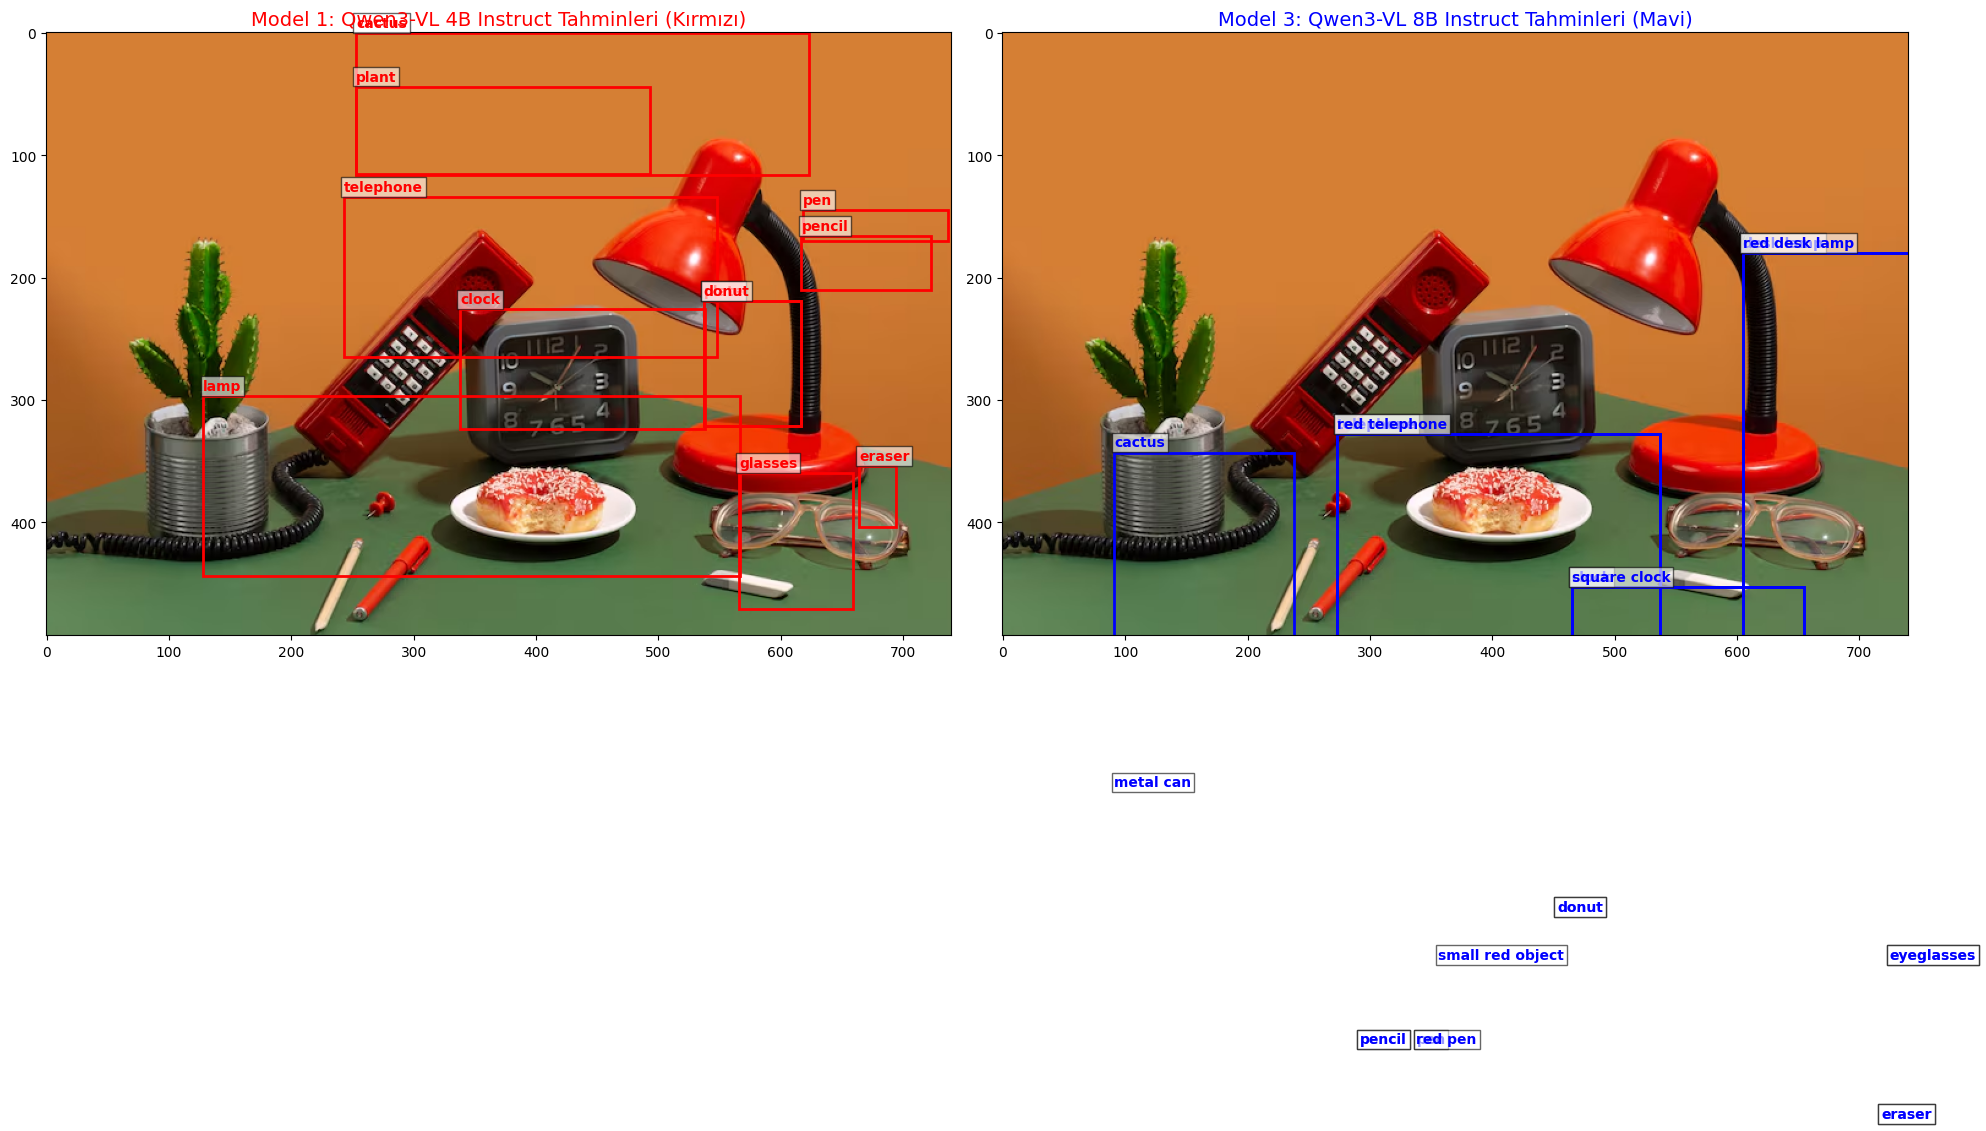

      ÇİFT MODELLİ BENCHMARK PERFORMANS VE BAŞARI ORANI RAPORU
NESNE ADI                 | QWEN3-VL 4B Instruct BAŞARISI | QWEN3-VL 8B Instruct BAŞARISI
---------------------------------------------------------------------------
potted plant              | (1/1) Buldu            | (1/1) Buldu           
telephone                 | (1/1) Buldu            | (1/1) Buldu           
clock                     | (1/1) Buldu            | (1/1) Buldu           
lamp                      | (1/1) Buldu            | (0) Iskaladı          
glasses                   | (1/1) Buldu            | (0) Iskaladı          
pencil                    | (1/1) Buldu            | (1/1) Buldu           
eraser                    | (1/1) Buldu            | (1/1) Buldu           
pushpin                   | (0) Iskaladı           | (0) Iskaladı          
dining table              | (0) Iskaladı           | (0) Iskaladı          

[QWEN3-VL 4B Instruct] DETAYLI METRİKLER:
  * Başarıyla Eşleşen Nesneler (Oranlar) : {

In [13]:
import torch
from PIL import Image
from qwen_vl_utils import process_vision_info

# --- AYARLAR VE MANUEL GROUND TRUTH ---
TEST_IMAGE_PATH = "/content/still-life-messy-office-desk_52683-107200.avif"  # Colab'deki resim yolu

manuel_ground_truth = {
    "potted plant": 1,
    "telephone": 1,
    "clock": 1,
    "lamp": 1,
    "glasses": 1,
    "pencil": 1,
    "eraser": 1,
    "pushpin": 1,
    "dining table": 1
}
# ---------------------------------------

# Ortak Prompt
DETECTION_PROMPT = (
    "Detect the objects in the image. For each object, return its bounding box coordinates "
    "and name in the exact format: <|box_start|>(ymin,xmin,ymax,xmax)<|box_end|>**object_name**."
)

img_pil = Image.open(TEST_IMAGE_PATH)
img_w, img_h = img_pil.size

# Model 1: QWEN3-VL-Instruct TAHMİN ADIMI
messages_instruct = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": TEST_IMAGE_PATH},
            {"type": "text", "text": DETECTION_PROMPT}
        ]
    }
]

text_instruct = process1.apply_chat_template(messages_instruct, tokenize=False, add_generation_prompt=True)
image_inputs_instruct, video_inputs_instruct = process_vision_info(messages_instruct)
inputs_instruct = process1(text=[text_instruct], images=image_inputs_instruct, videos=video_inputs_instruct, padding=True, return_tensors="pt")

if "pixel_values" in inputs_instruct:
    inputs_instruct["pixel_values"] = inputs_instruct["pixel_values"].to(torch.float16)

inputs_instruct = inputs_instruct.to(device)

with torch.no_grad():
    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
        generated_ids_instruct = model1.generate(**inputs_instruct, max_new_tokens=4096, use_cache=True)
    generated_ids_trimmed_instruct = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs_instruct.input_ids, generated_ids_instruct)]
    output_text_instruct = process1.batch_decode(
        generated_ids_trimmed_instruct, skip_special_tokens=False, clean_up_tokenization_spaces=False
    )[0]

print(f"\nModel 1 (Qwen Instruct) Ham Çıktısı:\n{output_text_instruct}\n")
qwen_instruct_tahminleri = parse_qwen_boxes(output_text_instruct, img_w, img_h)

# Model 3: QWEN3-VL-8B-Instruct TAHMİN ADIMI
messages_thinking = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": TEST_IMAGE_PATH},
            {"type": "text", "text": DETECTION_PROMPT}
        ]
    }
]

text_thinking = process3.apply_chat_template(messages_thinking, tokenize=False, add_generation_prompt=True)
image_inputs_thinking, video_inputs_thinking = process_vision_info(messages_thinking)
inputs_thinking = process3(text=[text_thinking], images=image_inputs_thinking, videos=video_inputs_thinking, padding=True, return_tensors="pt")

if "pixel_values" in inputs_thinking:
    inputs_thinking["pixel_values"] = inputs_thinking["pixel_values"].to(torch.float16)

inputs_thinking = inputs_thinking.to(device)

with torch.no_grad():
    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
        generated_ids_thinking = model3.generate(**inputs_thinking, max_new_tokens=4096, use_cache=True)
    generated_ids_trimmed_thinking = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs_thinking.input_ids, generated_ids_thinking)]
    output_text_thinking = process3.batch_decode(
        generated_ids_trimmed_thinking, skip_special_tokens=False, clean_up_tokenization_spaces=False
    )[0]

print(f"\nModel 3 (Qwen 8B Instruct) Ham Çıktısı:\n{output_text_thinking}\n")
qwen_thinking_tahminleri = parse_qwen_boxes(output_text_thinking, img_w, img_h)

# Model 2: YOLOv8m TAHMİN ADIMI (Artık kullanılmıyor, Qwen modelleri karşılaştırılacak)
yolo_tahminleri = []

# 3. GÖRSEL KUTULARI ÇİZDIRME (Qwen Instruct vs Qwen 8B Instruct)
plot_dual_boxes(TEST_IMAGE_PATH, qwen_instruct_tahminleri, qwen_thinking_tahminleri)

# 4. TEK OUTPUTTA METRİK RAPORLAMASI (Qwen Instruct vs Qwen 8B Instruct)
draw_and_analyze_dual(TEST_IMAGE_PATH, qwen_instruct_tahminleri, qwen_thinking_tahminleri, manuel_ground_truth)
